# Steel Plate Faults: Exploratory Data Analysis

## Objective

This project explores a steel plate faults dataset to understand how fault types vary with steel grade, plate thickness, defect size, and defect geometry.

My main questions were:

1. How do fault types differ between A300 and A400 steel?
2. Do different plate thicknesses show different fault distributions?
3. Do different fault types have characteristic sizes or shapes?

This is primarily an exploratory data analysis project. The dataset contains fault instances, but it does not provide the total number of non-faulty plates inspected. Therefore, the analysis can describe patterns in the recorded faults, but it cannot be used to calculate true defect rates or establish causation.

## 1. Dataset Overview

I first loaded the dataset and inspected its shape, columns, and data types to understand what information was available.

In [109]:
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/uciml/faulty-steel-plates/faults.csv


In [110]:
df = pd.read_csv('/kaggle/input/datasets/uciml/faulty-steel-plates/faults.csv')
df.shape
df.head()
df.columns
df.dtypes


X_Minimum                  int64
X_Maximum                  int64
Y_Minimum                  int64
Y_Maximum                  int64
Pixels_Areas               int64
X_Perimeter                int64
Y_Perimeter                int64
Sum_of_Luminosity          int64
Minimum_of_Luminosity      int64
Maximum_of_Luminosity      int64
Length_of_Conveyer         int64
TypeOfSteel_A300           int64
TypeOfSteel_A400           int64
Steel_Plate_Thickness      int64
Edges_Index              float64
Empty_Index              float64
Square_Index             float64
Outside_X_Index          float64
Edges_X_Index            float64
Edges_Y_Index            float64
Outside_Global_Index     float64
LogOfAreas               float64
Log_X_Index              float64
Log_Y_Index              float64
Orientation_Index        float64
Luminosity_Index         float64
SigmoidOfAreas           float64
Pastry                     int64
Z_Scratch                  int64
K_Scatch                   int64
Stains    

## 2. Data Quality Checks

Before analysing patterns, I checked the number of records, duplicate rows, and missing values.

In [111]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("steel_faults",conn,index=False,if_exists="replace")

1941

In [112]:
x = """
SELECT COUNT(*) AS total_rows
FROM steel_faults;
"""

pd.read_sql_query(x, conn)

,total_rows
0,1941


In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df.isnull().sum()

X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Pastry                   0
Z_Scratch                0
K_Scatch                 0
Stains                   0
Dirtiness                0
Bumps                    0
Other_Faults             0
dtype: int64

## 3. Overall Fault Distribution

I first counted the number of instances of each of the seven fault types to understand the overall composition of the dataset.

In [115]:
fault_check="""
SELECT
SUM(Pastry) AS pastry_count,
SUM(Z_Scratch ) AS Z_scratch_count,
SUM(K_Scatch) AS K_scatch_count,
SUM(Stains) AS stains_count,
SUM(Dirtiness) AS dirtiness_count,
SUM(bumps) AS bumps_count,
SUM(Other_Faults) AS Other_Faults_count
FROM steel_faults;
"""

fault_counts = pd.read_sql_query(fault_check,conn)
fault_counts
 

,pastry_count,Z_scratch_count,K_scatch_count,stains_count,dirtiness_count,bumps_count,Other_Faults_count
0,158,190,391,72,55,402,673


## 4. Fault Distribution by Steel Type

The dataset contains two steel types, A300 and A400. I wanted to understand how many recorded fault instances belonged to each material and whether the mix of fault types differed between them.

Because the total number of plates inspected for each steel type is not available, raw counts alone cannot be interpreted as defect rates. I therefore also compared the percentage distribution of fault types within each material.

In [116]:
steel_A300_check="""
SELECT TypeOfSteel_A300,
SUM(Pastry) AS pastry_count,
SUM(Z_Scratch ) AS Z_scratch_count,
SUM(K_Scatch) AS K_scatch_count,
SUM(Stains) AS stains_count,
SUM(Dirtiness) AS dirtiness_count,
SUM(bumps) AS bumps_count,
SUM(Other_Faults) AS Other_Faults_count
FROM steel_faults
GROUP BY TypeOfSteel_A300;
"""

steel_A300 = pd.read_sql_query(steel_A300_check,conn)
steel_A300

,TypeOfSteel_A300,pastry_count,Z_scratch_count,K_scatch_count,stains_count,dirtiness_count,bumps_count,Other_Faults_count
0,0,109,18,390,71,46,123,407
1,1,49,172,1,1,9,279,266


In [117]:
steel_compare = """
SELECT TypeOfSteel_A300, TypeOfSteel_A400,
COUNT(*) AS number_of_rows
FROM steel_faults
GROUP BY TypeOfSteel_A300, TypeOfSteel_A400;
"""
steel_compare_read = pd.read_sql_query(steel_compare, conn)
steel_compare_read

,TypeOfSteel_A300,TypeOfSteel_A400,number_of_rows
0,0,1,1164
1,1,0,777


## 5. Plate Thickness and Fault Distribution

I next explored plate thickness. I wanted to understand:

- which thicknesses are represented in the dataset,
- how many fault records occur at each thickness,
- whether fault types are distributed differently across thicknesses.

In [118]:
th_check= """
SELECT Steel_Plate_Thickness, COUNT(*)
FROM steel_faults
WHERE TypeOfSteel_A300=1
GROUP BY Steel_Plate_Thickness;
"""
th_check_read = pd.read_sql_query(th_check, conn)
th_check_read

,Steel_Plate_Thickness,COUNT(*)
0,50,5
1,60,71
2,69,39
3,70,331
4,80,150
5,85,4
6,100,94
7,120,11
8,143,18
9,150,12


In [119]:
th_check2= """
SELECT Steel_Plate_Thickness,
SUM(Pastry) AS pastry_count,
SUM(Z_Scratch ) AS Z_scratch_count,
SUM(K_Scatch) AS K_scatch_count,
SUM(Stains) AS stains_count,
SUM(Dirtiness) AS dirtiness_count,
SUM(bumps) AS bumps_count,
SUM(Other_Faults) AS Other_Faults_count,
COUNT(*) AS total_faults
FROM steel_faults
GROUP BY Steel_Plate_Thickness;
"""
th_check2_read = pd.read_sql_query(th_check2, conn)
th_check2_read = th_check2_read.sort_values("Steel_Plate_Thickness")
th_check2_read

,Steel_Plate_Thickness,pastry_count,Z_scratch_count,K_scatch_count,stains_count,dirtiness_count,bumps_count,Other_Faults_count,total_faults
0,40,34,8,387,0,12,78,191,710
1,50,5,0,3,71,1,14,21,115
2,60,13,0,0,0,0,60,14,87
3,69,4,0,0,0,8,12,15,39
4,70,19,170,0,0,0,70,121,380
5,80,4,0,1,0,0,91,54,150
6,85,0,0,0,0,0,4,0,4
7,90,22,0,0,0,0,0,1,23
8,100,18,2,0,1,27,38,68,154
9,120,3,0,0,0,6,4,12,25


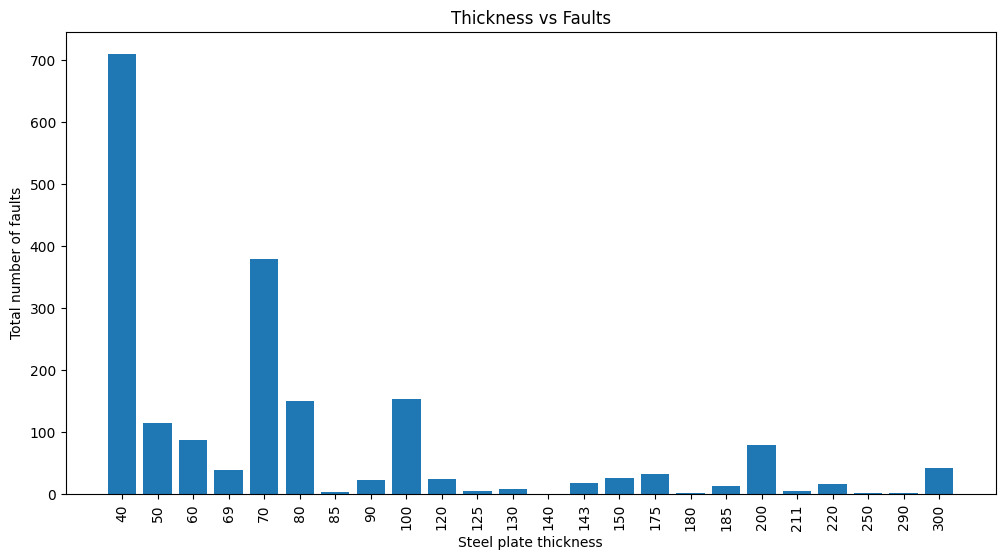

In [120]:
th_check2_read = th_check2_read.sort_values("Steel_Plate_Thickness")
thickness_labels = th_check2_read["Steel_Plate_Thickness"].astype(str)
plt.figure(figsize=(12, 6))

plt.bar(thickness_labels, th_check2_read["total_faults"])
plt.xlabel("Steel plate thickness")
plt.ylabel("Total number of faults")
plt.title("Thickness vs Faults")
plt.xticks(rotation=90)
plt.show()

### Observation

Some thicknesses contain far more recorded fault instances than others. This means that comparisons between thicknesses need to be treated carefully, especially where only a few observations are available.

In [121]:
A300 = steel_A300[steel_A300["TypeOfSteel_A300"] == 1]



fault_cols = [
    "pastry_count",
    "Z_scratch_count",
    "K_scatch_count",
    "stains_count",
    "dirtiness_count",
    "bumps_count",
    "Other_Faults_count"
]

A300_faults = A300[fault_cols]

In [122]:
A300_long = A300_faults.melt(
    var_name="fault_type",
    value_name="count"
)


A300_long["percentage"] = (A300_long["count"] / 777) * 100
A300_long

,fault_type,count,percentage
0,pastry_count,49,6.306306
1,Z_scratch_count,172,22.136422
2,K_scatch_count,1,0.128700
3,stains_count,1,0.128700
4,dirtiness_count,9,1.158301
5,bumps_count,279,35.907336
6,Other_Faults_count,266,34.234234


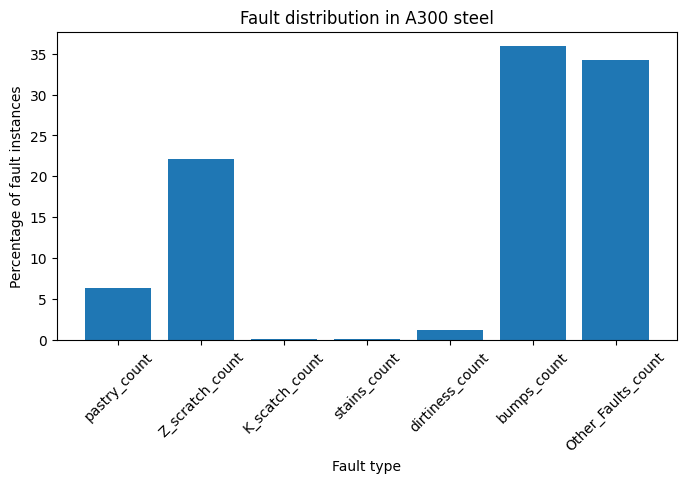

In [123]:
plt.figure(figsize=(8, 4))

plt.bar(
    A300_long["fault_type"],
    A300_long["percentage"]
)

plt.xlabel("Fault type")
plt.ylabel("Percentage of fault instances")
plt.title("Fault distribution in A300 steel")

plt.xticks(rotation=45)
plt.show()

In [124]:
A400 = steel_A300[steel_A300["TypeOfSteel_A300"] == 0]



fault_cols = [
    "pastry_count",
    "Z_scratch_count",
    "K_scatch_count",
    "stains_count",
    "dirtiness_count",
    "bumps_count",
    "Other_Faults_count"
]

A400_faults = A400[fault_cols]

A400_long = A400_faults.melt(
    var_name="fault_type",
    value_name="count"
)


A400_long["percentage"] = (A400_long["count"] / 1164) * 100
A400_long


,fault_type,count,percentage
0,pastry_count,109,9.364261
1,Z_scratch_count,18,1.546392
2,K_scatch_count,390,33.505155
3,stains_count,71,6.099656
4,dirtiness_count,46,3.951890
5,bumps_count,123,10.567010
6,Other_Faults_count,407,34.965636


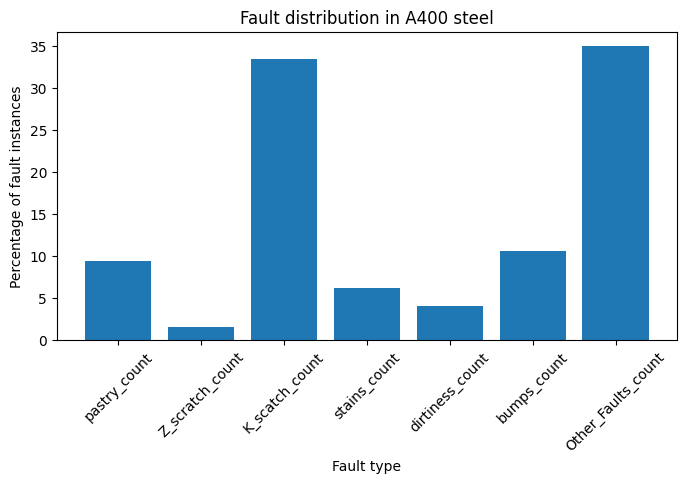

In [125]:
plt.figure(figsize=(8, 4))

plt.bar(
    A400_long["fault_type"],
    A400_long["percentage"]
)

plt.xlabel("Fault type")
plt.ylabel("Percentage of fault instances")
plt.title("Fault distribution in A400 steel")

plt.xticks(rotation=45)
plt.show()

### Observation

The two materials show different fault distributions. However, these results only describe the recorded faulty instances. They do not show that one steel type is more likely to fail than the other because the total number of inspected A300 and A400 plates is unknown.

In [126]:
steel_plate_thickness = """
SELECT
    Steel_Plate_Thickness,
    SUM(TypeOfSteel_A300) AS A300_count,
    SUM(TypeOfSteel_A400) AS A400_count
FROM steel_faults
GROUP BY Steel_Plate_Thickness
ORDER BY Steel_Plate_Thickness;
"""

steel_plate_thickness_df = pd.read_sql_query(steel_plate_thickness, conn)

steel_plate_thickness_df

,Steel_Plate_Thickness,A300_count,A400_count
0,40,0,710
1,50,5,110
2,60,71,16
3,69,39,0
4,70,331,49
5,80,150,0
6,85,4,0
7,90,0,23
8,100,94,60
9,120,11,14


In [127]:
heatmap_df = th_check2_read.copy()

fault_cols = [
    "pastry_count",
    "Z_scratch_count",
    "K_scatch_count",
    "stains_count",
    "dirtiness_count",
    "bumps_count",
    "Other_Faults_count"
]

for col in fault_cols:
    heatmap_df[col] = (
        heatmap_df[col] / heatmap_df["total_faults"]
    ) * 100

In [128]:
heatmap_data = heatmap_df.set_index(
    "Steel_Plate_Thickness"
)[fault_cols]

### Fault Composition by Thickness

To make the different thickness groups easier to compare, I converted the fault counts within each thickness into percentages and visualised them as a heatmap.

Each row represents a steel plate thickness and each column represents a fault type. The colour and value indicate what percentage of the recorded faults at that thickness belong to each category.

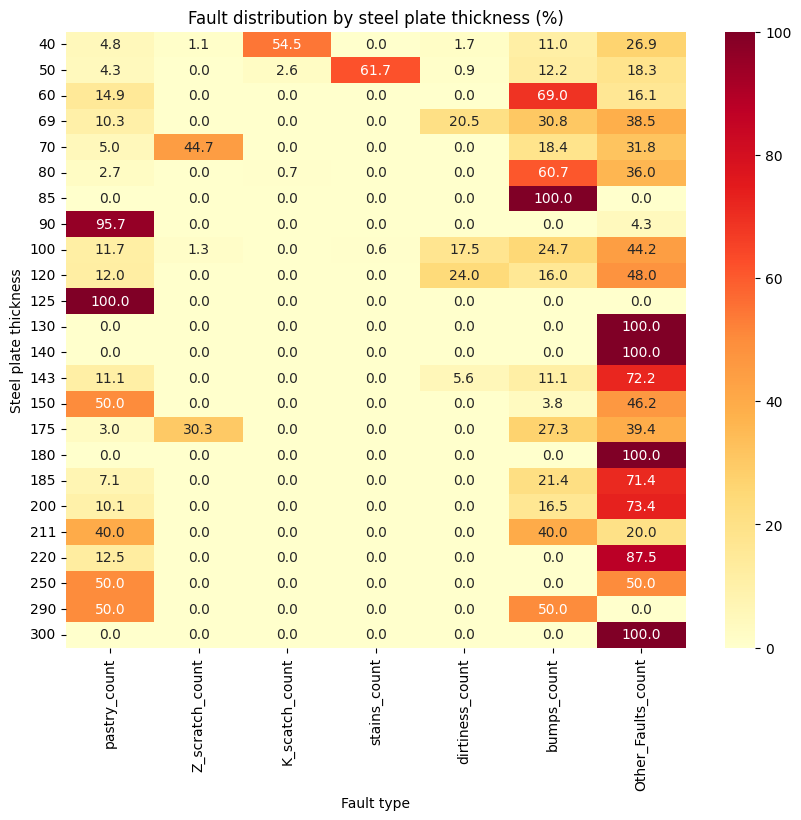

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f"
)

plt.xlabel("Fault type")
plt.ylabel("Steel plate thickness")
plt.title("Fault distribution by steel plate thickness (%)")

plt.show()

### Observation

The heatmap makes differences in fault composition across thicknesses easier to see. Some thicknesses appear dominated by particular fault categories.

However, several thickness groups have very small sample sizes, so strong conclusions should not be drawn from those rows.

## 6. Fault Size Analysis

I then investigated whether different fault types tend to occupy different areas.

`Pixels_Areas` represents the number of image pixels associated with a detected fault. I reshaped the data so that each fault instance could be linked directly to its fault type and pixel area.

The aim here was to understand whether some fault types tend to be consistently larger or smaller than others, and how much variation exists within each category.

In [130]:
fault_cols = [
    "Pastry",
    "Z_Scratch",
    "K_Scatch",
    "Stains",
    "Dirtiness",
    "Bumps",
    "Other_Faults"
]

fault_long = df.melt(
    id_vars=["Pixels_Areas"],
    value_vars=fault_cols,
    var_name="fault_type",
    value_name="is_fault"
)

fault_long = fault_long[fault_long["is_fault"] == 1]

fault_long = fault_long[["fault_type", "Pixels_Areas"]]

fault_long

,fault_type,Pixels_Areas
0,Pastry,267
1,Pastry,108
2,Pastry,71
3,Pastry,176
4,Pastry,2409
...,...,...
13582,Other_Faults,273
13583,Other_Faults,287
13584,Other_Faults,292
13585,Other_Faults,419


In [131]:
fault_long.groupby("fault_type")["Pixels_Areas"].describe()

,count,mean,std,min,25%,50%,75%,max
fault_type,,,,,,,,
Bumps,402.0,238.465174,561.446680,25.0,78.25,120.5,197.50,8391.0
Dirtiness,55.0,363.490909,384.570221,52.0,84.50,145.0,581.50,2028.0
K_Scatch,391.0,7622.654731,9100.607359,2.0,3948.50,6281.0,10908.50,152655.0
Other_Faults,673.0,584.371471,2040.210152,15.0,81.00,146.0,308.00,37334.0
Pastry,158.0,561.620253,1314.772648,30.0,112.50,209.0,381.25,10914.0
Stains,72.0,19.916667,14.147861,6.0,13.50,16.5,18.00,86.0
Z_Scratch,190.0,506.594737,1039.794647,51.0,75.25,146.0,442.00,7579.0


### Understanding the Distribution

A box plot is useful here because I am interested not only in the average size of a fault, but also in how much the size varies within each fault type.

The centre line represents the median, the box contains the middle 50% of observations, and points beyond the whiskers represent unusually large or small observations.

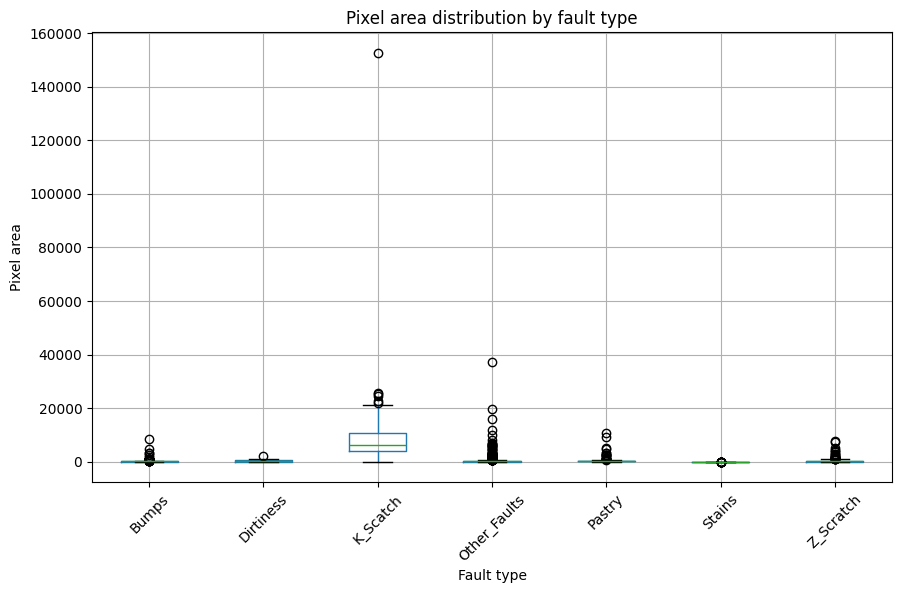

In [132]:
fault_long.boxplot(
    column="Pixels_Areas",
    by="fault_type",
    figsize=(10, 6)
)

plt.xlabel("Fault type")
plt.ylabel("Pixel area")
plt.title("Pixel area distribution by fault type")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

In [133]:
fault_long.sort_values("Pixels_Areas", ascending=False).head(10)

,fault_type,Pixels_Areas
4273,K_Scatch,152655
13238,Other_Faults,37334
4276,K_Scatch,25473
4274,K_Scatch,25323
4277,K_Scatch,24365
4280,K_Scatch,22554
4281,K_Scatch,21987
4275,K_Scatch,21110
4282,K_Scatch,21036
4278,K_Scatch,20894


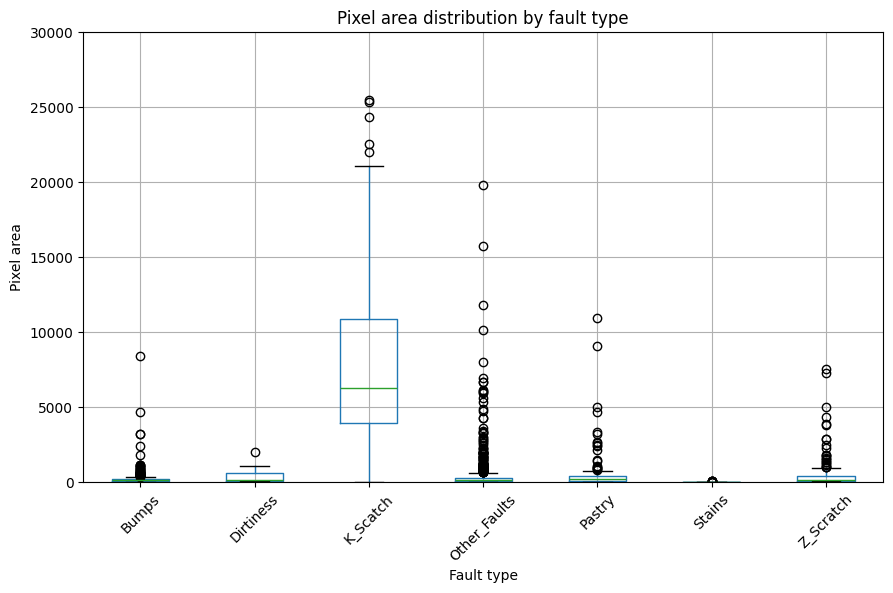

In [134]:
fault_long.boxplot(
    column="Pixels_Areas",
    by="fault_type",
    figsize=(10, 6)
)

plt.ylim(0, 30000)
plt.xlabel("Fault type")
plt.ylabel("Pixel area")
plt.title("Pixel area distribution by fault type")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

### Observation

K_Scatch stands out as having substantially larger typical pixel areas than most other fault types.

Several categories also contain large outliers. I kept these observations in the dataset rather than deleting them, because there is not enough information to determine whether they are errors or genuine extreme defects.

The zoomed plot helps compare the typical distributions without removing the extreme values from the underlying data.

## 7. Fault Geometry Analysis

Pixel area gives an overall measure of defect size, but it does not describe the shape of the fault.

I therefore created two additional measures:

- `fault_width = X_Maximum - X_Minimum`
- `fault_height = Y_Maximum - Y_Minimum`

I then compared the width and height distributions across the seven fault categories to see whether different faults show characteristic geometries.

In [135]:
df["fault_width"] = df["X_Maximum"] - df["X_Minimum"]
df["fault_height"] = df["Y_Maximum"] - df["Y_Minimum"]


In [136]:
fault_cols = [
    "Pastry",
    "Z_Scratch",
    "K_Scatch",
    "Stains",
    "Dirtiness",
    "Bumps",
    "Other_Faults"
]

geometry_long = df.melt(
    id_vars=["fault_width", "fault_height"],
    value_vars=fault_cols,
    var_name="fault_type",
    value_name="is_fault"
)

geometry_long = geometry_long[geometry_long["is_fault"] == 1]

geometry_long = geometry_long[["fault_type", "fault_width", "fault_height"]]

geometry_long

,fault_type,fault_width,fault_height
0,Pastry,8,44
1,Pastry,6,29
2,Pastry,6,18
3,Pastry,7,45
4,Pastry,17,257
...,...,...,...
13582,Other_Faults,28,16
13583,Other_Faults,31,17
13584,Other_Faults,29,15
13585,Other_Faults,33,31


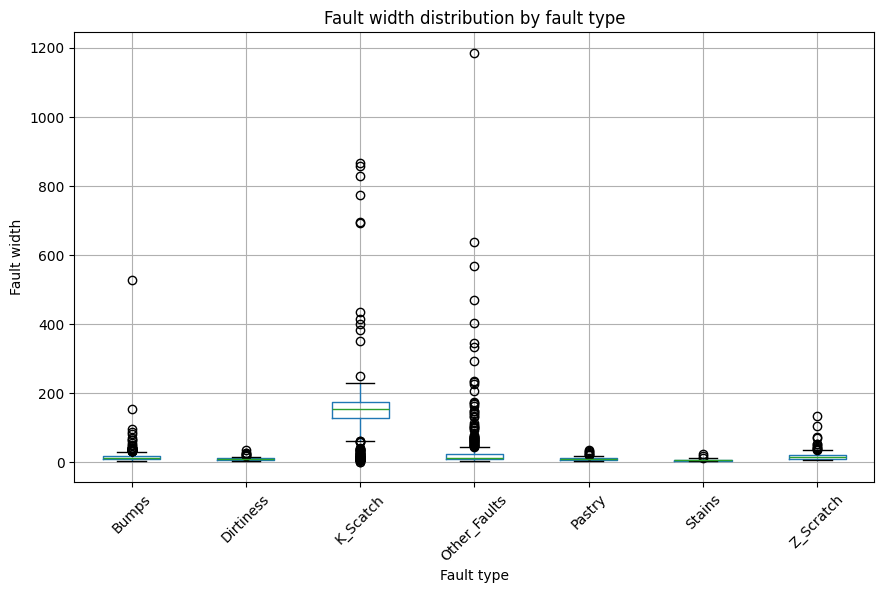

In [137]:
geometry_long.boxplot(
    column="fault_width",
    by="fault_type",
    figsize=(10, 6)
)

plt.xlabel("Fault type")
plt.ylabel("Fault width")
plt.title("Fault width distribution by fault type")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

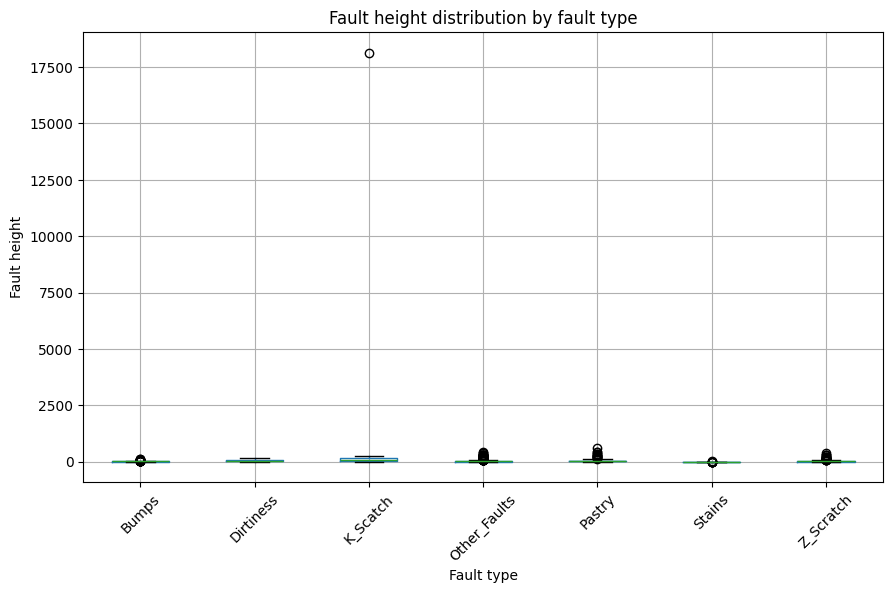

In [138]:
geometry_long.boxplot(
    column="fault_height",
    by="fault_type",
    figsize=(10, 6)
)

plt.xlabel("Fault type")
plt.ylabel("Fault height")
plt.title("Fault height distribution by fault type")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

In [139]:
geometry_long.sort_values("fault_height", ascending=False).head(10)

,fault_type,fault_width,fault_height
4273,K_Scatch,150,18141
83,Pastry,31,597
135,Pastry,18,426
6,Pastry,33,415
13238,Other_Faults,134,412
2150,Z_Scratch,37,391
12935,Other_Faults,35,376
13439,Other_Faults,24,376
145,Pastry,16,357
140,Pastry,14,356


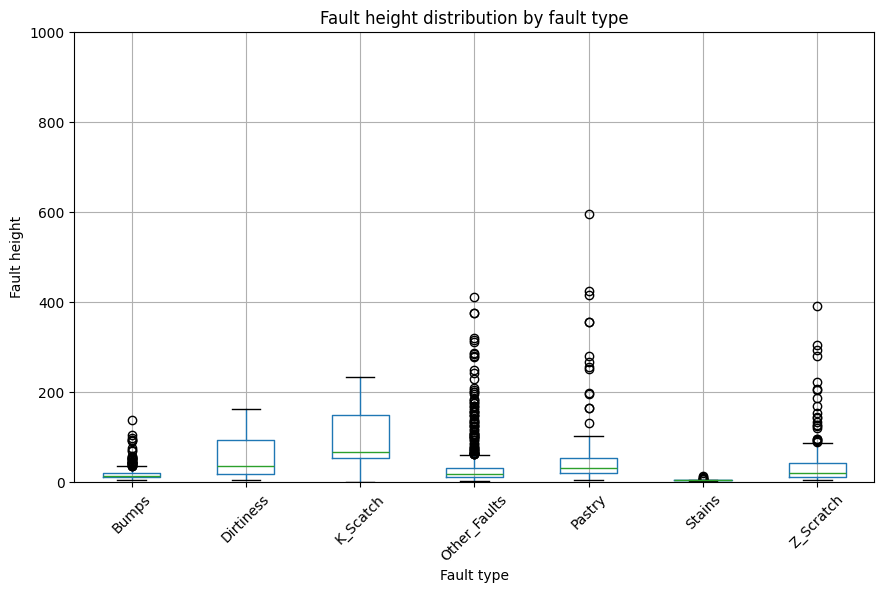

In [140]:
#K_Scatch observation has an exceptionally large height and heavily skews the scale
geometry_long.boxplot(
    column="fault_height",
    by="fault_type",
    figsize=(10, 6)
)

plt.ylim(0, 1000)  
plt.xlabel("Fault type")
plt.ylabel("Fault height")
plt.title("Fault height distribution by fault type")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

### Observation

The geometry analysis shows that fault dimensions vary considerably across categories.

One K_Scatch observation has an exceptionally large fault height compared with the rest of the dataset. I kept this value in the analysis but used a zoomed plot to make the typical height distributions easier to compare.

The width and height plots suggest that different fault types can have distinct geometric characteristics.

In [141]:
geometry_long.groupby("fault_type")[["fault_width", "fault_height"]].describe()

fault_width                                                     \
                   count        mean         std  min    25%    50%     75%   
fault_type                                                                    
Bumps              402.0   17.773632   28.821854  5.0   10.0   12.5   18.75   
Dirtiness           55.0   11.236364    6.451998  4.0    7.0   10.0   12.00   
K_Scatch           391.0  148.468031  102.996158  2.0  129.5  155.0  175.00   
Other_Faults       673.0   28.624071   68.187154  3.0   10.0   14.0   24.00   
Pastry             158.0   11.069620    4.696003  5.0    8.0   10.0   13.00   
Stains              72.0    7.069444    3.432760  3.0    5.0    6.0    8.00   
Z_Scratch          190.0   18.726316   14.962346  6.0   11.0   15.0   21.00   

                     fault_height                                           \
                 max        count        mean         std  min   25%   50%   
fault_type                                                                   
Bumps          529.0        402.0   19.184080   15.082349  5.0  11.0  14.0   
Dirtiness       36.0         55.0   56.709091   47.245487  4.0  19.0  35.0   
K_Scatch       868.0        391.0  136.442455  914.771829  1.0  53.0  67.0   
Other_Faults  1186.0        673.0   34.294205   51.676992  2.0  11.0  18.0   
Pastry          36.0        158.0   57.094937   84.309544  6.0  20.0  30.5   
Stains          25.0         72.0    4.833333    1.868946  2.0   4.0   4.0   
Z_Scratch      135.0        190.0   41.415789   57.149120  5.0  12.0  20.0   

                               
                 75%      max  
fault_type                     
Bumps          21.00    138.0  
Dirtiness      94.00    163.0  
K_Scatch      149.50  18141.0  
Other_Faults   31.00    412.0  
Pastry         54.00    597.0  
Stains          5.00     13.0  
Z_Scratch      42.75    391.0

## 8. Key Findings

- A300 and A400 contain different distributions of recorded fault types.
- Some plate thicknesses have many more fault observations than others.
- Fault composition varies across thickness groups, although some groups contain very few observations.
- K_Scatch defects tend to have much larger pixel areas than most other fault categories.
- Different fault categories also show different width and height distributions.

## 9. Limitations

The dataset contains only recorded fault instances. It does not provide the total number of plates inspected for each steel type or thickness.

As a result, this analysis cannot determine true defect rates or conclude that a particular steel type or thickness causes a particular fault.

The dataset is therefore more suitable for exploring fault characteristics and potentially training a classification model than for establishing manufacturing causes.

## 10. Reflection

This project reinforced that the questions an analysis can answer are limited by the data available. I initially wanted to compare fault likelihood across materials and thicknesses, but the dataset only contains recorded fault instances, so I could describe patterns without estimating true defect rates or causation.

It also gave me useful practice combining SQL and pandas, reshaping data, comparing percentages, and choosing visualisations for different analytical questions. The dataset would be a good candidate for a future classification project, but I chose to stop here at the exploratory analysis stage.